In [6]:
# Importing requird Python modules
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from colorama import Fore, Back, Style

In [7]:
# Helper function for generating binary number representation (as list of ints)
def int_to_bin_list(n: int, bit_size: int) -> list[int]:
    # 1. Convert number to binary string
    # 2. Cut of "0b" prefix
    # 3. Iterate over 0/1 char representing bits
    # 4. Convert char-coded bit back too int
    # 5. Agregate all int-coded bits in list, [MSB...LSB] order
    bits = [int(bit) for bit in bin(n)[2:]]

    # 6. Apply padding if needed
    if len(bits) < bit_size:
        bits = [0] * (bit_size - len(bits)) + bits

    return bits

def int_to_bin_tensor(n: int, bit_size: int) -> torch.tensor:
    n_bin_list = int_to_bin_list(n, bit_size)
    return torch.tensor(n_bin_list, dtype=torch.int32)

In [8]:
# Preparing training set
BIT_SIZE = 4
summands = [i for i in range(0,(2**BIT_SIZE))]

x = []
y = []
for a in summands:
    for b in summands:
        ab_merged = (a << BIT_SIZE) | b 
        ab_sum = a + b

        ab_merged = int_to_bin_list(ab_merged, 2*BIT_SIZE)
        ab_sum = int_to_bin_list(ab_sum, BIT_SIZE + 1)

        x.append(ab_merged)
        y.append(ab_sum)

x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

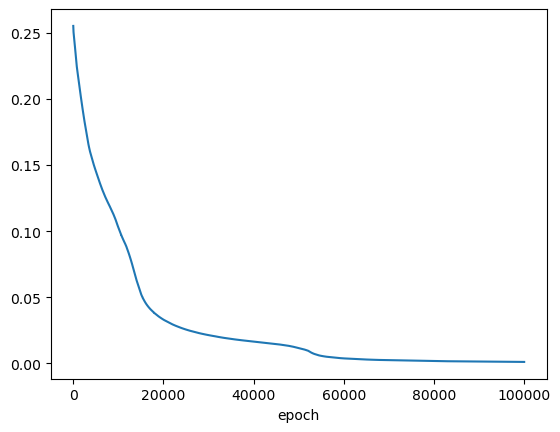

0, 0, 0
0, 1, 1
0, 2, 2
0, 3, 3
0, 4, 4
0, 5, 5
0, 6, 6
0, 7, 7
0, 8, 8
0, 9, 9
0, 10, 10
0, 11, 11
0, 12, 12
0, 13, 13
0, 14, 14
0, 15, 15
1, 0, 1
1, 1, 2
1, 2, 3
1, 3, 4
1, 4, 5
1, 5, 6
1, 6, 7
1, 7, 8
1, 8, 9
1, 9, 10
1, 10, 11
1, 11, 12
1, 12, 13
1, 13, 14
1, 14, 15
1, 15, 16
2, 0, 2
2, 1, 3
2, 2, 4
2, 3, 5
2, 4, 6
2, 5, 7
2, 6, 8
2, 7, 9
2, 8, 10
2, 9, 11
2, 10, 12
2, 11, 13
2, 12, 14
2, 13, 15
2, 14, 16
2, 15, 17
3, 0, 3
3, 1, 4
3, 2, 5
3, 3, 6
3, 4, 7
3, 5, 8
3, 6, 9
3, 7, 10
3, 8, 11
3, 9, 12
3, 10, 13
3, 11, 14
3, 12, 15
3, 13, 16
3, 14, 17
3, 15, 18
4, 0, 4
4, 1, 5
4, 2, 6
4, 3, 7
4, 4, 8
4, 5, 9
4, 6, 10
4, 7, 11
4, 8, 12
4, 9, 13
4, 10, 14
4, 11, 15
4, 12, 16
4, 13, 17
4, 14, 18
4, 15, 19
5, 0, 5
5, 1, 6
5, 2, 7
5, 3, 8
5, 4, 9
5, 5, 10
5, 6, 11
5, 7, 12
5, 8, 13
5, 9, 14
5, 10, 15
5, 11, 16
5, 12, 17
5, 13, 18
5, 14, 19
5, 15, 20
6, 0, 6
6, 1, 7
6, 2, 8
6, 3, 9
6, 4, 10
6, 5, 11
6, 6, 12
6, 7, 13
6, 8, 14
6, 9, 15
6, 10, 16
6, 11, 17
6, 12, 18
6, 13, 19
6, 14, 20
6, 15, 21

In [9]:
# Create model which will serve as binary aadder 
class NNBinAdder(torch.nn.Module):
    def __init__(self, bit_size: int, hidden_size: int):
        super(NNBinAdder, self).__init__()
        # First layer has to be able to accept two binary numbers hence 2*bin_width
        self.hidden_layer = nn.Linear(2*bit_size, hidden_size)
        self.mid_activation = nn.ReLU()
        # i.e. 255+255 = 510 (9 bits) - always +1 bit is needed
        self.output_layer = nn.Linear(hidden_size, bit_size+1)
        self.activation = nn.Sigmoid()
    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.mid_activation(x)
        x = self.output_layer(x)
        return self.activation(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x, y = x.to(device), y.to(device)

model = NNBinAdder(bit_size=BIT_SIZE, hidden_size=20).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.2)
MSE = nn.MSELoss()

# train
N_epochs = 100000
train_loss = []
model.train()  # turn on the training mode
for _ in range(N_epochs):
    # this will zero out the gradients for this batch
    optimizer.zero_grad()
    # make predictions
    y_pred = model(x)
    # calculate the MSE loss
    loss = MSE(y_pred, y)
    # backpropagate the loss
    loss.backward()
    # update the model weights (with assumed learning rate)
    optimizer.step()
    train_loss.append(loss.item())

plt.plot(train_loss)
plt.xlabel('epoch')
plt.show()

model.eval()


yp = model(x).cpu().detach().numpy().round().astype(int)
x = x.cpu().numpy().round().astype(int)
y = y.cpu().numpy().round().astype(int)

# Print all pairs
errors = 0
for xi, yi, ypi in zip(x, y, yp):
    x1 = xi[:BIT_SIZE]
    x2 = xi[BIT_SIZE:]

    x1 = int("".join(str(b) for b in x1), 2)
    x2 = int("".join(str(b) for b in x2), 2)
    y = int("".join(str(b) for b in yi), 2)
    yp = int("".join(str(b) for b in ypi), 2)

    is_ok = (x1 + x2 == yp)
    if is_ok:
        print(Fore.GREEN + f"{x1}, {x2}, {yp}")
    else:
        print(Fore.RED + f"{x1}, {x2}, {yp}")
        errors = errors + 1
print(f"Errors {errors}")